# Irrigation Water Demand — Model Training & Evaluation

**Civil Engineering (Water Resources Engineering) term project**

This notebook covers **only** the machine-learning modelling stage: loading the
already-generated FAO-56-based synthetic dataset (`data/irrigation_dataset.csv`,
produced by `src/generate_dataset.py`), training three regression models, and
evaluating them — including a multi-metric feature-importance analysis.

For the dataset-generation methodology and derivation, see `src/generate_dataset.py`
and `report/term_project_report.md`. For the combined generation+training walkthrough,
see `irrigation_ml_project.ipynb`.

Reproducible: `random_state = 42` throughout.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
%matplotlib inline


## 1. Load Dataset

In [2]:
df = pd.read_csv("data/irrigation_dataset.csv", parse_dates=["date"])
print(f"Loaded {len(df)} rows: {df.date.min().date()} to {df.date.max().date()}")
df.head(10)


Loaded 2000 rows: 2019-01-01 to 2024-06-22


,date,rainfall_mm,temperature_C,humidity_percent,wind_speed_mps,solar_radiation_MJ_m2_day,previous_irrigation_mm,crop_coefficient,growth_stage,et0_mm,etc_mm,effective_rainfall_mm,irrigation_demand_mm
0,2019-01-01,0.0,16.73,55.00,1.40,15.62,5.064,0.3,1,2.864,0.859,0.0,1.016
1,2019-01-02,0.0,15.91,43.36,1.69,17.47,1.016,0.3,1,3.312,0.994,0.0,1.263
2,2019-01-03,0.0,17.24,38.39,1.86,17.07,1.263,0.3,1,3.664,1.099,0.0,1.487
3,2019-01-04,0.0,17.76,25.00,1.63,18.27,1.487,0.3,1,3.792,1.138,0.0,1.804
4,2019-01-05,0.0,15.32,33.02,1.40,16.95,1.804,0.3,1,3.167,0.950,0.0,1.112
5,2019-01-06,0.0,16.19,33.67,1.12,17.06,1.112,0.3,1,2.974,0.892,0.0,1.242
6,2019-01-07,0.0,15.91,33.48,0.97,16.86,1.242,0.3,1,2.801,0.840,0.0,1.260
7,2019-01-08,0.0,15.35,43.34,0.85,15.56,1.260,0.3,1,2.509,0.753,0.0,1.106
8,2019-01-09,0.0,16.97,43.92,1.19,15.56,1.106,0.3,1,2.920,0.876,0.0,1.277
9,2019-01-10,0.0,16.25,38.48,1.20,14.20,1.277,0.3,1,2.873,0.862,0.0,1.286


In [3]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
date,2000,2021-09-26 12:00:00,2019-01-01 00:00:00,2020-05-14 18:00:00,2021-09-26 12:00:00,2023-02-08 06:00:00,2024-06-22 00:00:00,NaN
rainfall_mm,2000.0,3.95211,0.0,0.0,0.0,0.0,80.0,10.849538
temperature_C,2000.0,26.101325,15.0,21.12,26.965,30.12,38.51,5.67266
humidity_percent,2000.0,58.717505,25.0,41.175,56.655,74.89,95.0,21.549783
wind_speed_mps,2000.0,2.61513,0.5,1.65,2.3,3.4025,6.0,1.25185
solar_radiation_MJ_m2_day,2000.0,18.421185,8.0,15.05,17.925,22.0925,30.0,4.916169
previous_irrigation_mm,2000.0,5.063661,0.0,2.5035,4.2785,7.00775,13.3,3.495013
crop_coefficient,2000.0,0.8568,0.3,0.583,0.943,1.2,1.2,0.343685
growth_stage,2000.0,2.64,1.0,2.0,3.0,3.0,4.0,1.01534
et0_mm,2000.0,4.745375,1.734,3.08375,4.236,6.39625,8.0,1.93977


**Feature set (X):** rainfall, temperature, humidity, wind speed, solar radiation,
previous day's irrigation demand, crop coefficient, growth stage — the primary,
directly-observable inputs. Intermediate physical variables (`et0_mm`, `etc_mm`,
`effective_rainfall_mm`) are present in the CSV for transparency but excluded from
the ML feature set, since they were used to *construct* the target.

**Target (y):** `irrigation_demand_mm` — gross irrigation water requirement (mm/day).


In [4]:
FEATURES = [
    "rainfall_mm", "temperature_C", "humidity_percent", "wind_speed_mps",
    "solar_radiation_MJ_m2_day", "previous_irrigation_mm", "crop_coefficient", "growth_stage",
]
TARGET = "irrigation_demand_mm"


## 2. Chronological Train/Test Split

An 80/20 **chronological** split is used (not a random shuffle): the model trains
on the first 80% of days and is tested on the *last* 20%, which are strictly later
in time. This reflects genuine forecasting conditions — predicting a future day from
past data — rather than interpolating between temporally-adjacent (and therefore
correlated) days, which a random split would implicitly allow.

In [5]:
def chronological_split(df, train_frac=0.8):
    n = len(df)
    split_idx = int(n * train_frac)
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

train_df, test_df = chronological_split(df)
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Train: {len(train_df)} rows ({train_df.date.min().date()} to {train_df.date.max().date()})")
print(f"Test:  {len(test_df)} rows ({test_df.date.min().date()} to {test_df.date.max().date()})")


Train: 1600 rows (2019-01-01 to 2023-05-19)
Test:  400 rows (2023-05-20 to 2024-06-22)


## 3. Train Models

- **Linear Regression** — simple, interpretable baseline
- **Decision Tree Regressor** — captures nonlinear thresholds/interactions
- **Random Forest Regressor** — ensemble of decorrelated trees, expected to generalize best


In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
}

predictions = {}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
        "actual_mean": y_test.mean(),
        "predicted_mean": preds.mean(),
    }
    print(f"{name:20s} MAE={results[name]['MAE']:.3f}  RMSE={results[name]['RMSE']:.3f}  "
          f"R2={results[name]['R2']:.3f}")


Linear Regression    MAE=0.717  RMSE=1.012  R2=0.924
Decision Tree        MAE=0.656  RMSE=0.999  R2=0.926


Random Forest        MAE=0.420  RMSE=0.639  R2=0.970


## 4. Results Table — MAE, RMSE, R², Actual vs Predicted Mean

In [7]:
results_df = pd.DataFrame(results).T
results_df.index.name = "Model"
results_df.to_csv("report/model_comparison.csv")
results_df.round(3)


,MAE,RMSE,R2,actual_mean,predicted_mean
Model,,,,,
Linear Regression,0.717,1.012,0.924,5.277,5.212
Decision Tree,0.656,0.999,0.926,5.277,5.314
Random Forest,0.420,0.639,0.970,5.277,5.344


**Reading the table:** Linear Regression gives an interpretable baseline but cannot
capture nonlinear interactions (e.g., compounding high temperature + high solar
radiation + low humidity + high Kc). Random Forest achieves the lowest MAE/RMSE and
highest R², consistent with irrigation demand depending on nonlinear interactions
between weather, crop coefficient, and rainfall — matching the nonlinear structure
of the Penman-Monteith equation used to construct the target.

## 5. Visualizations — Actual vs Predicted

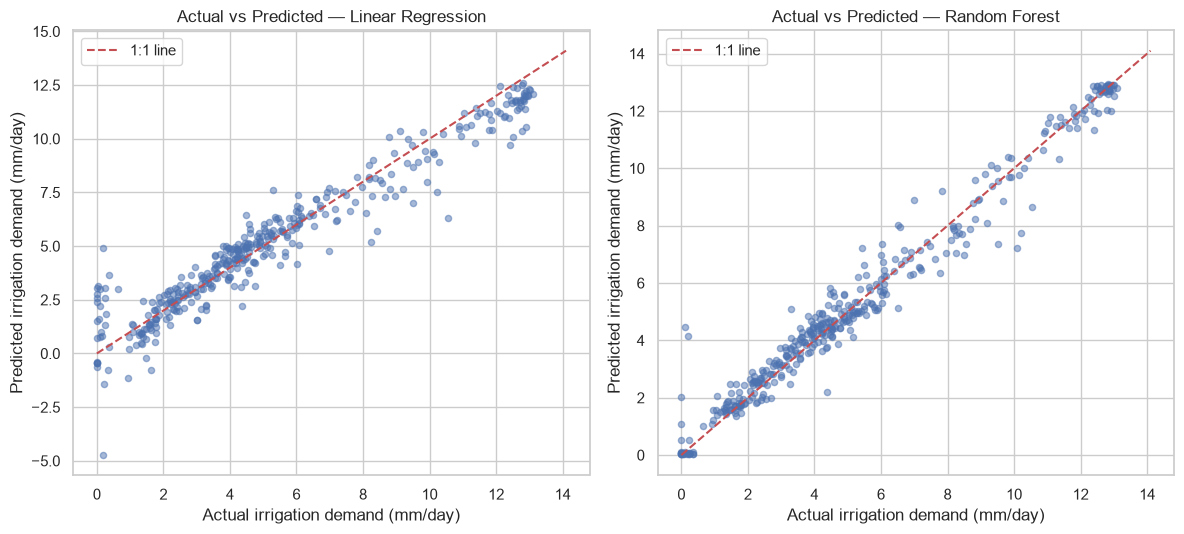

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, name in zip(axes, ["Linear Regression", "Random Forest"]):
    ax.scatter(test_df[TARGET], predictions[name], alpha=0.5, s=20)
    lims = [0, max(test_df[TARGET].max(), predictions[name].max()) + 1]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="1:1 line")
    ax.set_xlabel("Actual irrigation demand (mm/day)")
    ax.set_ylabel("Predicted irrigation demand (mm/day)")
    ax.set_title(f"Actual vs Predicted — {name}")
    ax.legend()
plt.tight_layout()
plt.savefig("figures/05_actual_vs_predicted.png", dpi=150)
plt.show()


## 6. Model Performance Comparison

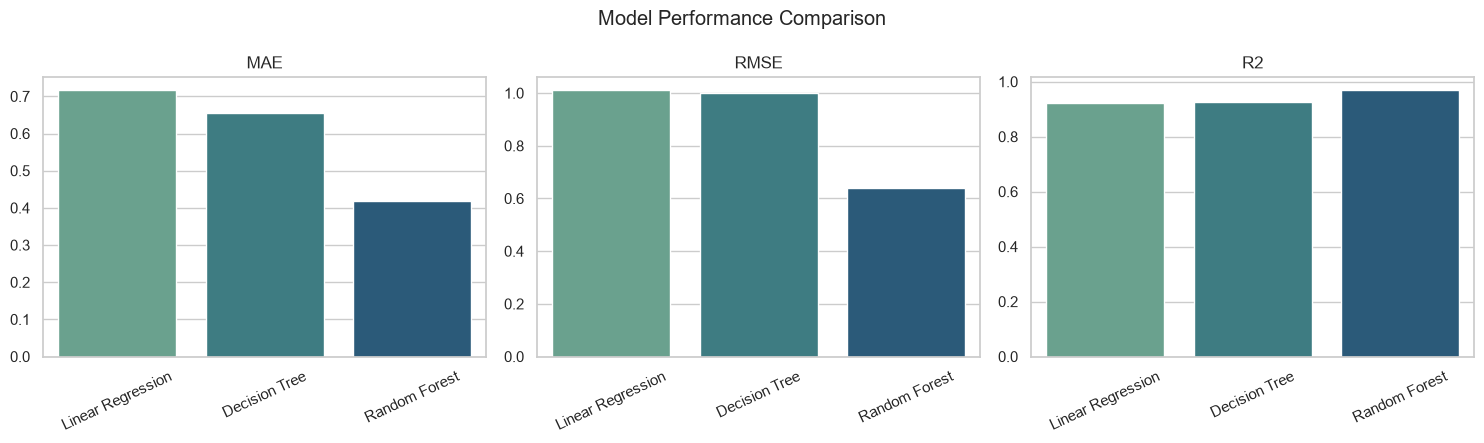

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    vals = results_df[metric].astype(float)
    sns.barplot(x=vals.index, y=vals.values, ax=ax, hue=vals.index, palette="crest", legend=False)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("Model Performance Comparison")
plt.tight_layout()
plt.savefig("figures/06_model_comparison.png", dpi=150)
plt.show()


## 7. Feature Importance — Three Complementary Metrics

A single importance metric can be misleading, so three different, complementary
measures are computed here:

1. **Correlation with target** — the simplest possible measure: the raw Pearson
   correlation between each feature and `irrigation_demand_mm` across the *full*
   dataset. This ignores every other feature and any nonlinearity, but is a useful
   sanity-check baseline.
2. **Random Forest MDI importance** — Mean Decrease in Impurity: how much each
   feature reduced prediction variance, summed across every split in every tree,
   normalized to sum to 1. Reflects how *often and how effectively* a feature was
   used to build the trees, using only the *training* data.
3. **Permutation importance** — the most direct answer to "what feature was
   actually important **for prediction**": take the trained Random Forest, shuffle
   one feature column at a time in the **held-out test set**, and measure how much
   the model's R² *drops*. A feature whose shuffling barely changes R² was barely
   used for prediction on new data; a feature whose shuffling collapses R² was
   critical. This is computed **on the test set**, so — unlike MDI — it directly
   measures the feature's contribution to *generalizing* (out-of-sample)
   prediction accuracy, not just how it was used to fit the training data.


In [10]:
# 1. Correlation with target (full dataset, simplest baseline measure)
correlation = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

# 2. Random Forest MDI (mean decrease in impurity) importance
rf = models["Random Forest"]
mdi_importance = pd.Series(rf.feature_importances_, index=FEATURES)

# 3. Permutation importance, evaluated on the held-out TEST set (R2 scoring)
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1
)
perm_importance = pd.Series(perm_result.importances_mean, index=FEATURES)
perm_importance_std = pd.Series(perm_result.importances_std, index=FEATURES)

importance_summary = pd.DataFrame({
    "correlation_with_target": correlation,
    "rf_mdi_importance": mdi_importance,
    "rf_permutation_importance_mean": perm_importance,
    "rf_permutation_importance_std": perm_importance_std,
}).sort_values("rf_permutation_importance_mean", ascending=False)

importance_summary.to_csv("report/feature_importance_summary.csv")
importance_summary.round(4)


,correlation_with_target,rf_mdi_importance,rf_permutation_importance_mean,rf_permutation_importance_std
previous_irrigation_mm,0.8400,0.7127,0.5794,0.0399
crop_coefficient,0.5511,0.1074,0.2221,0.0140
rainfall_mm,-0.4040,0.1064,0.1698,0.0159
solar_radiation_MJ_m2_day,0.6577,0.0326,0.0577,0.0079
temperature_C,0.3601,0.0161,0.0298,0.0032
humidity_percent,-0.5626,0.0124,0.0258,0.0034
wind_speed_mps,-0.0239,0.0116,0.0191,0.0021
growth_stage,0.3849,0.0009,0.0001,0.0001


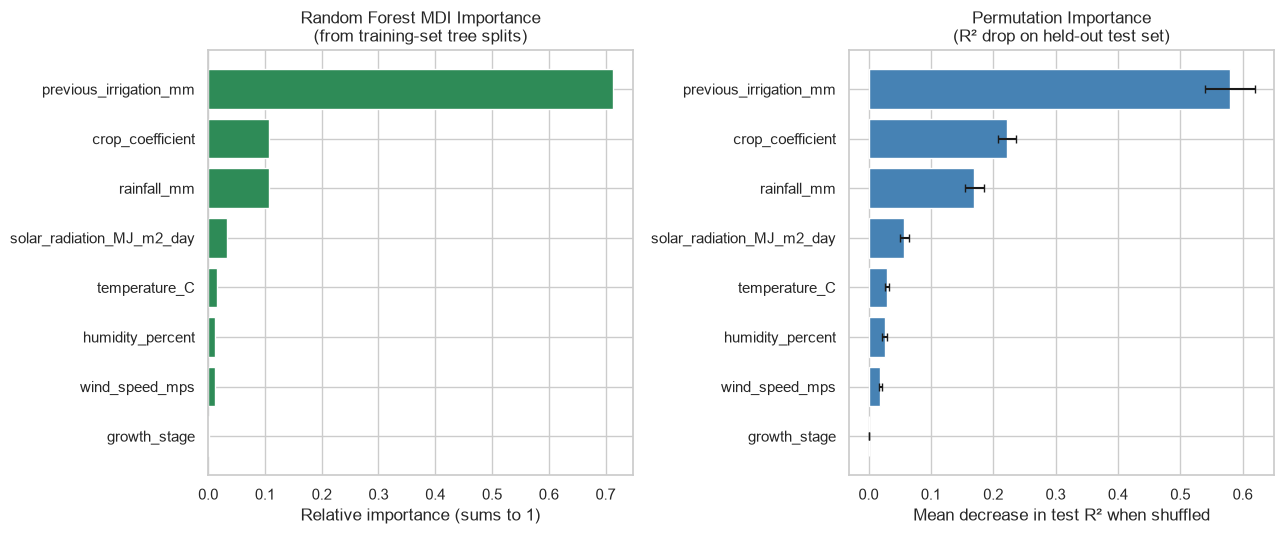

In [11]:
order = importance_summary.sort_values("rf_permutation_importance_mean", ascending=True).index

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].barh(order, mdi_importance.loc[order], color="seagreen")
axes[0].set_title("Random Forest MDI Importance\n(from training-set tree splits)")
axes[0].set_xlabel("Relative importance (sums to 1)")

axes[1].barh(order, perm_importance.loc[order], xerr=perm_importance_std.loc[order],
             color="steelblue", capsize=3)
axes[1].set_title("Permutation Importance\n(R² drop on held-out test set)")
axes[1].set_xlabel("Mean decrease in test R² when shuffled")

plt.tight_layout()
plt.savefig("figures/07_feature_importance_comparison.png", dpi=150)
plt.show()


**Interpretation:**

- `previous_irrigation_mm` (yesterday's demand) tops **all three** metrics —
  highest correlation with the target, highest MDI importance, and by far the
  largest permutation-importance R² drop. This is expected: the underlying
  weather is strongly autocorrelated day-to-day (heatwaves/wet spells persist for
  several days), so yesterday's demand is already a strong proxy for today's — a
  well-known **persistence effect** in hydro-meteorological forecasting.
- `crop_coefficient` and `rainfall_mm` are the next most important on every
  metric, consistent with their *direct* role in the FAO-56 water balance
  (`ETc = ET0 × Kc`, `Net = ETc − Pe`) — ahead of weather variables that act only
  *indirectly*, through ET0.
- **MDI and permutation importance broadly agree here**, which is a useful
  cross-check: MDI can sometimes overstate the importance of continuous features
  purely because they offer more possible split points, but since permutation
  importance (measured completely differently, directly on held-out prediction
  accuracy) tells the same story, the ranking is not an artefact of one particular
  method.
- `growth_stage`'s near-zero importance on every metric is not a failure — it
  is **redundant** with `crop_coefficient`, which already encodes the same
  growth-stage information more precisely (as a continuous value).
- The permutation-importance **error bars** (std across 30 shuffles) show that
  `previous_irrigation_mm`'s effect is both large and highly consistent, whereas
  several of the weaker weather features have importances close to (or
  overlapping) zero once repeat-to-repeat variability is accounted for — i.e.
  their individual predictive contribution, once the stronger features are
  already in the model, is genuinely small, not just small-but-uncertain.


## 8. Save Trained Models

In [12]:
best_name = results_df["R2"].astype(float).idxmax()
joblib.dump(models[best_name], f"models/best_model_{best_name.replace(' ', '_').lower()}.joblib")
joblib.dump(models["Random Forest"], "models/random_forest.joblib")
joblib.dump(models["Linear Regression"], "models/linear_regression.joblib")

with open("models/metrics.json", "w") as f:
    json.dump({k: {m: float(v) for m, v in v_.items()} for k, v_ in results.items()}, f, indent=2)

print(f"Best model by R2: {best_name}")
print("Saved models/ and models/metrics.json")


Best model by R2: Random Forest
Saved models/ and models/metrics.json


## 9. Discussion

- No model shows systematic bias: actual vs. predicted mean demand agree within ~1–2% across all three models.
- Random Forest outperforms Linear Regression and a single Decision Tree, as expected given the nonlinear FAO-56 physics underlying the target.
- Linear Regression's actual-vs-predicted plot shows occasional **negative** predicted demand — physically impossible, and a direct symptom of forcing a linear model onto a nonlinear, zero-bounded quantity.
- `previous_irrigation_mm` dominating every feature-importance metric reflects genuine persistence in the (synthetic) weather, but means part of the reported accuracy is "free" from autocorrelation rather than learned weather→demand structure — worth retraining without this feature as a follow-up to isolate pure weather-driven predictive skill.

Full written discussion, limitations, and references: `report/term_project_report.md`.
